## Инициализация окружения

In [1]:
from scipy.stats import uniform, norm
from sklearn.decomposition import PCA
import numpy as np
from numpy.random import MT19937, RandomState, SeedSequence
import matplotlib.pyplot as plt

In [2]:
# task init
SEED = 1
GENERATOR = RandomState(MT19937(SeedSequence(SEED)))

## Генерация данных

Случайный вектор $(\xi_1, \xi_2, \xi_3, \xi_4, \xi_5, \eta)$ имеет априорные законы распределения:
$$
\xi_k \sim R(-1, 1), \newline
\eta \sim N(2 + 3x_1 + 2x_2 + x_3 + x_4 - x_5, 1.5^2);
$$
требуется сгенерировать выборку объёма $n = 50$.

In [3]:
# prior xi distribution
K = 5
X_DISTRIBUTION = uniform(loc=-1, scale=2)

# prior eta distribution
BETA_PRIOR = np.array([3, 2, 1, 1, -1])
BIAS_PRIOR = 2
STD_PRIOR = 1.5

def y_prior(x):
    return x @ BETA_PRIOR + BIAS_PRIOR

Y_DISTRIBUTION = norm

# sample size
N = 50

# x generation
X = X_DISTRIBUTION.rvs(size=(N, K), random_state=GENERATOR)
Y = Y_DISTRIBUTION.rvs(y_prior(X), STD_PRIOR, random_state=GENERATOR)

### Визуализация

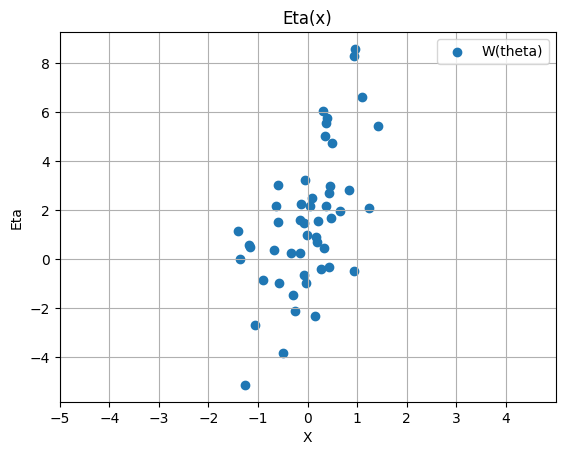

In [4]:
x_decomposed = PCA(n_components=1).fit_transform(X)

fig, axis = plt.subplots()

axis.scatter(x_decomposed, Y, label="W(theta)")

axis.set_ylabel("Eta")

axis.set_xlim(-5, 5)
axis.set_xticks(np.arange(-5, 5, 1))
axis.set_xlabel("X")

axis.legend()
axis.set_title("Eta(x)")

axis.grid(True)

plt.show()